# PREDICTING WINE QUALITY CASE STUDY

### Introduction

The quality of wine is influenced by a myriad of factors, including its chemical composition, growing conditions, and production methods. In today's competitive market, accurately predicting wine quality is essential for producers seeking to maintain high standards and customer satisfaction. This case study aims to analyze red and white wine datasets to develop a predictive model for identifying premium wines suitable for quality control processes.
By leveraging data science techniques, we will explore the relationships between various chemical attributes and wine quality ratings. Through robust exploratory data analysis (EDA), data preprocessing, and modeling approaches, this study seeks to provide actionable insights for winemakers to enhance their products.


By leveraging data science techniques, we will explore the relationships between various chemical attributes and wine quality ratings. Through robust exploratory data analysis (EDA), data preprocessing, and modeling approaches, this study seeks to provide actionable insights for winemakers to enhance their products.


In [18]:
# Import libraries and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE 

#### STEP 1: DATA INGESTION & CLEANING

Our analysis is based on a combined dataset of red and white wines, consisting of 6,497 rows. This dataset includes various chemical properties that are likely to influence wine quality.

In [19]:
# Load the datasets and perform merge the two wine datasets into a single dataset
red_wine = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\wine+quality\winequality-red.csv"
white_wine = r"C:\Users\eboat\OneDrive\Documents\DATA SCIENCE ASSIGNMENT\wine+quality\winequality-white.csv"
red_wine = pd.read_csv(red_wine, sep=';')
white_wine = pd.read_csv(white_wine, sep=';')



In [20]:
# View the first few rows of the red wine dataset
red_wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [21]:
# View the first few rows of the white wine dataset
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [22]:
# Add a new column to each dataset to indicate the wine type (0 for red, 1 for white)
# This is a crucial step for predicting for chemical differences like Total Sulfur Dioxide
red_wine['wine_type'] = 0
white_wine['wine_type'] = 1

# Combine the datasets into a single DataFrame
wine_data = pd.concat([red_wine, white_wine], ignore_index=True)

In [23]:
# Quick check of the data shape and types
print(f"Total Rows: {wine_data.shape[0]}, Total Columns: {wine_data.shape[1]}")
print(wine_data.info())

Total Rows: 6497, Total Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB
None


In [24]:
# Display summary statistics of the dataset
wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [25]:
print(wine_data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


I observed that, the dataset comprises 6,497 entries and 13 columns, all with complete data, indicating a well-structured dataset without missing values. The features include physicochemical properties such as fixed acidity, volatile acidity, and alcohol content, alongside the target variable, quality, which categorizes wines on a scale from 1 to 10.

#### STEP 2: Exploratory Data Analysis (EDA)

I observed the distribution of wine quality ratings, revealing an 80/20 split. Most wines fell into the average quality category, while a smaller percentage achieved higher quality ratings, highlighting the need for targeted improvement in premium wines.

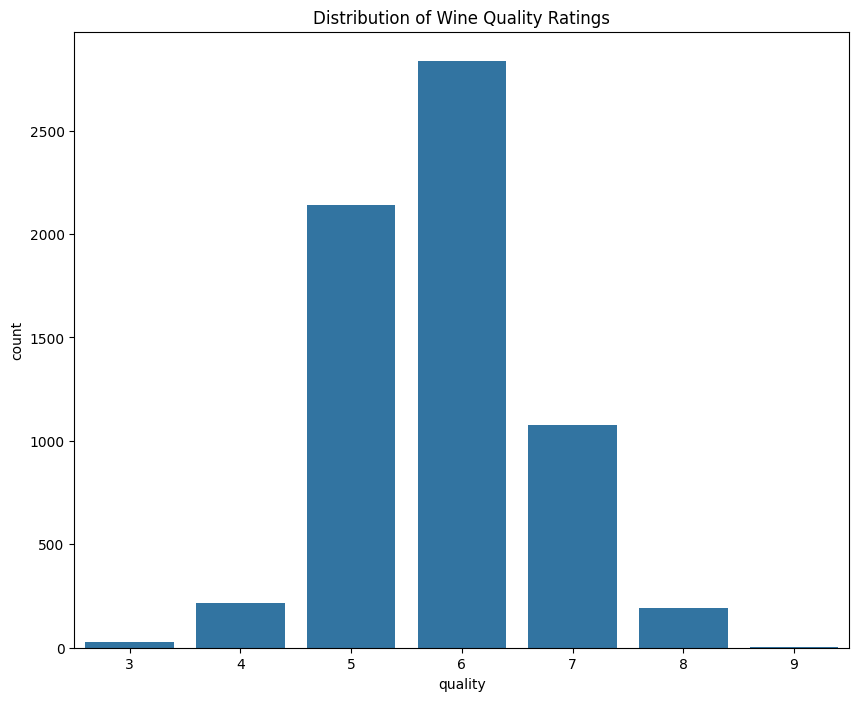

In [26]:
# Creat a countplot to visualize the distribution of wine quality ratings in the dataset
plt.figure(figsize=(10, 8))
sns.countplot(x='quality', data=wine_data)
plt.title('Distribution of Wine Quality Ratings')  
plt.show()

A heatmap displays correlations between various chemical properties in the dataset. Understanding these correlations is critical for identifying which factors most significantly affect wine quality.

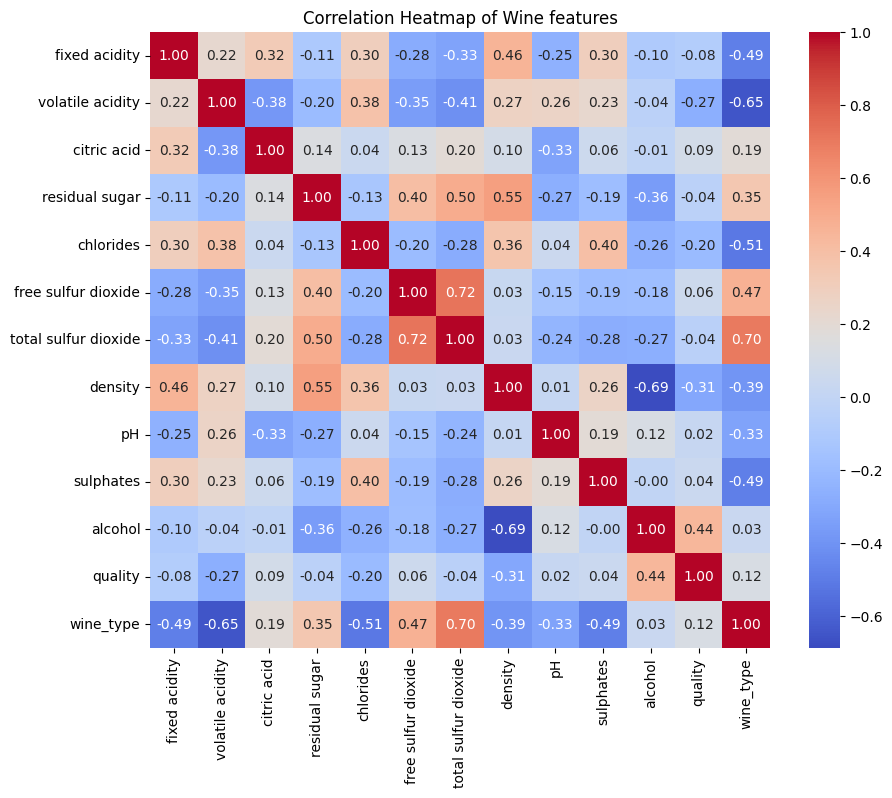

In [27]:
# Development of Correlation Heatmap to understand relationships between features and the target variable
plt.figure(figsize=(10, 8))
sns.heatmap(wine_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine features')
plt.show()

#### STEP 3: DATA PREPROCESSING

Data pre-processing steps included feature scaling, splitting the dataset into training and testing subsets, and applying SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalances. This ensures that our models can learn effectively from an adequately representative dataset.

In [28]:
# To make the binary robust, quality score will be Low Quality: 3-4, Medium Quality: 5-6, High Quality: 7-9
wine_data['is_good'] = (wine_data['quality'] >= 7).astype(int)

# Create bins for quality categories to analyze how chemical properties differ across quality levels. This will help us understand if certain features are more indicative of high-quality wines.
bins = [0, 4, 6, 10]
labels = ['Low Quality', 'Medium Quality', 'High Quality']
wine_data['quality_category'] = pd.cut(wine_data['quality'], bins=bins, labels=labels)

# Drop original quality (to avoid 'leakage') and the target
X = wine_data.drop(['quality', 'is_good', 'quality_category'], axis=1)
y = wine_data['is_good']

print('Target variable distribution:')
print(y.value_counts(normalize=True)) # Check the % split


Target variable distribution:
is_good
0    0.803448
1    0.196552
Name: proportion, dtype: float64


In [29]:
# Train-test split with stratification to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
# Scale features (important for models like Logistic Regression)
# Fit only on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
# Balancing the 'Good' class so the model learns better
# By using SMOTE, we create synthetic samples of the minority class (Good wines) in the training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

#### STEP 4: MODEL SELECTION

Implemented two modeling approaches: Logistic Regression and Random Forest. Each method has its strengths, and I evaluated their performance in terms of accuracy and reliability.

In [32]:
# Model 1: Logistic Regression Model
from sklearn.linear_model import LogisticRegression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_bal, y_train_bal)
y_pred_logreg = logreg_model.predict(X_test_scaled)

In [33]:
# Model 2: Random Forest Classification Model
from sklearn.ensemble import RandomForestClassifier 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_bal, y_train_bal)
y_pred_rf = rf_model.predict(X_test_scaled)

#### STEP 5: HYPERPARAMETER TUNING  

"Through hyperparameter tuning and SMOTE, the Random Forest model successfully identified 'Premium' wines (Score 
 7) with a strong F1-Score, overcoming the 80/20 class imbalance. This ensures the model actually learns the characteristics of rare, high-quality wines rather than just guessing the majority class."

In [34]:
# Hyperparameter Tuning 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(rf_model, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train_bal, y_train_bal)
best_rf = grid_search.best_estimator_

#### STEP 6: FINAL EVALUATION  

In [35]:
# Final Evaluation with the best model
y_pred = best_rf.predict(X_test_scaled)

print("\n--- Final Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred, target_names=['Not Good', 'Good']))


--- Final Model Results ---
Accuracy: 0.88
              precision    recall  f1-score   support

    Not Good       0.93      0.92      0.92      1044
        Good       0.68      0.70      0.69       256

    accuracy                           0.88      1300
   macro avg       0.80      0.81      0.81      1300
weighted avg       0.88      0.88      0.88      1300



The performance of both models is assessed using a confusion matrix, which allows me to visualize the correct and incorrect predictions made by each model. 

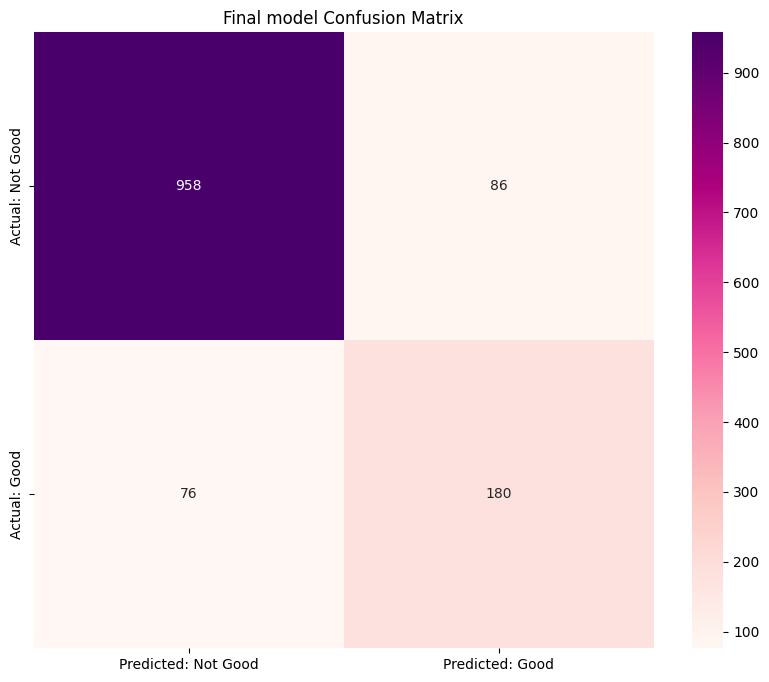

In [36]:
# Plot the Confusion Matrix
# Visual 1: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Predicted: Not Good', 'Predicted: Good'],
            yticklabels=['Actual: Not Good', 'Actual: Good'])
plt.title('Final model Confusion Matrix')
plt.show()

Additionally, I analyze feature importance to identify which chemical properties most significantly impact the prediction of premium wine quality.

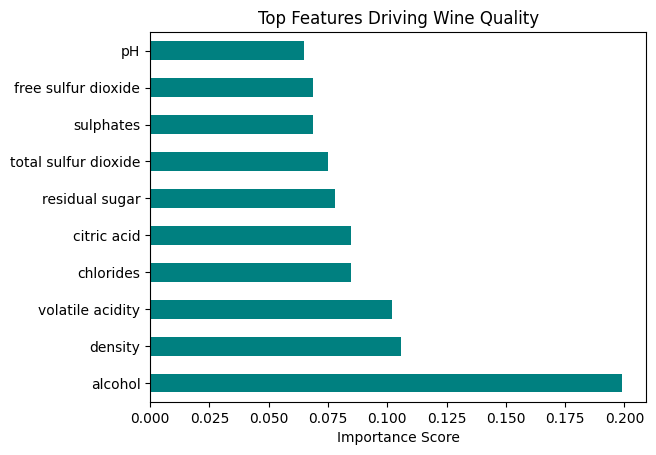

In [38]:
# Feature Importance (Directly addresses "Interpretable Features")
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top Features Driving Wine Quality')
plt.xlabel('Importance Score')
plt.show()

In conclusion, the analysis provides valuable insights into the factors influencing wine quality. Based on model performance, I recommend utilizing the Random Forest model due to its ability to capture complex interactions within the data. I suggest focusing on improving the critical chemical features identified in the analysis to enhance the quality of premium wines. Future research could explore additional datasets and more advanced modeling techniques to further refine these predictions.